In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ["OPENBLAS_NUM_THREADS"] = "4"  # or a lower number like 2, 4, or 8

import sys, re, torch, time, PINN, palantir
import numpy as np
import pandas as pd
import scanpy as sc
from tqdm.auto import tqdm
# PINN
from PINN import reader, models, pl, tl
# plot
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.backends.backend_pdf import PdfPages

os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

# load data

In [2]:
ad_palantir = sc.read_h5ad("data/tom_pos_palantir_Jun4.h5ad")
ad_palantir

AnnData object with n_obs × n_vars = 49390 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [3]:
adata_lin = {}
v_project = {}
g_project = {}
x_project = {}
pdt_bin_lineage = {}

nbins = 15

for lineage in ['Neu', 'Meg', 'Ery']:
    ad = ad_palantir[ad_palantir.obsm['branch_masks'][lineage]].copy()
    pdt_max = ad.obs['palantir_pseudotime'].max()

    # Normalize the pseudotime

    projection_bins = 100
    x = np.linspace(0, pdt_max, projection_bins)
    x_project[lineage] = (x[1:] + x[:-1])/2
    v_project[lineage] = tl.aggregate_params_by_pseudotime(ad, ad.obsm['v_norm'].T, 
                                            param_names='v', timepoints=None, 
                                            pseudotime_key='palantir_pseudotime',
                                            nbins=projection_bins, return_y=True)

    g_project[lineage] = tl.aggregate_params_by_pseudotime(ad, ad.obsm['g'].T, 
                                            param_names='g', timepoints=None, 
                                            pseudotime_key='palantir_pseudotime',
                                            nbins=projection_bins, return_y=True)

    pdt_bins = np.linspace(0, pdt_max, nbins+1)
    pdt_bin_lineage[lineage] = pdt_bins
    pdt_label = np.round((pdt_bins[1:] + pdt_bins[:-1])/2, 2)
    ad.obs['pseudotime_bin'] = pd.cut(ad.obs['palantir_pseudotime']
                                            ,bins=nbins,labels = pdt_label).astype(float)
    
    adata_lin[lineage] = ad
    print(adata_lin[lineage].obs['pseudotime_bin'].unique())

[0.34 0.64 0.28 0.4  0.21 0.46 0.15 0.52 0.58 0.77 0.71 0.89 0.83 0.09
 0.03]
[0.38 0.34 0.31 0.27 0.42 0.45 0.23 0.52 0.49 0.2  0.16 0.13 0.09 0.05
 0.02]
[0.26 0.32 0.62 0.21 0.56 0.38 0.5  0.68 0.44 0.15 0.73 0.79 0.85 0.09
 0.03]


In [5]:
adata_lin["Meg"]

AnnData object with n_obs × n_vars = 8681 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'lo

# Meg

In [6]:
# pdt_max = adata_lin['Neu'].obs['palantir_pseudotime'].max()

# pdt_bins = np.linspace(0, pdt_max, 21)
# pdt_bin_lineage['Neu'] = pdt_bins
# pdt_label = np.round((pdt_bins[1:] + pdt_bins[:-1])/2, 2)
# adata_lin['Neu'].obs['pseudotime_bin'] = pd.cut(adata_lin['Neu'].obs['palantir_pseudotime']
#                                                     , bins=20,labels = pdt_label)


In [7]:
def obs_composition(adata, x_var, y_var, kind='bar', 
                    figkws={'figsize':[6,4]}, 
                    legend_kws={"bbox_to_anchor":(1.05, 1), "loc":'upper left'}, 
                    alpha = 0.9,
                    ax=None,
                    palette=None):  # ★★★ New parameter added ★★★
    """
    Plot cell type composition with customizable color palette
    
    Parameters:
    palette (dict): Dictionary mapping category names to hex color codes
                   Example: {'G1': '#1f77b4', 'G2M': '#ff7f0e', 'S': '#279e68'}
    """
    # Calculate proportions
    cell_type_prop = (
        adata.obs
        .groupby(x_var)[y_var]
        .value_counts(normalize=True)
        .mul(100)
        .rename('percentage')
        .reset_index()
    )

    # Pivot for plotting
    prop_pivot = cell_type_prop.pivot(
        index=x_var,
        columns=y_var,
        values='percentage'
    ).fillna(0)

    # ★★★ New Code: Reorder columns to enforce stacking order ★★★
    desired_order = ['S', 'G2M', 'G1']  # Define your desired order
    existing_columns = [col for col in desired_order if col in prop_pivot.columns]
    prop_pivot = prop_pivot[existing_columns]

    # ★★★ Handle color palette ★★★
    if palette is not None:
        # Use provided palette, ensuring colors match existing columns
        colors = [palette[col] for col in prop_pivot.columns if col in palette]
    elif f'{y_var}_colors' in adata.uns:
        # Fall back to adata colors if available
        colors = adata.uns[f'{y_var}_colors']
    else:
        colors = None

    # Create stacked area plot
    if ax is None:
        fig = plt.figure(**figkws)
        ax = plt.subplot()
    else:
        fig = ax.figure

    if kind == 'area':
        prop_pivot.plot.area(
            ax=ax,
            stacked=True,
            color=colors,
            linewidth=0,
            alpha=alpha
        )

    if kind == 'bar':
        prop_pivot.plot.bar(
            ax=ax,
            stacked=True,
            color=colors,
            width=0.85,
            edgecolor='white',
            alpha=alpha
        )

    # Format plot
    ax.set_xlabel(x_var)
    ax.set_ylabel('Proportion (%)')
    ax.legend(**legend_kws)
    plt.tight_layout()
    
    return fig, ax

[0.38 0.34 0.31 0.27 0.42 0.45 0.23 0.52 0.49 0.2  0.16 0.13 0.09 0.05
 0.02]


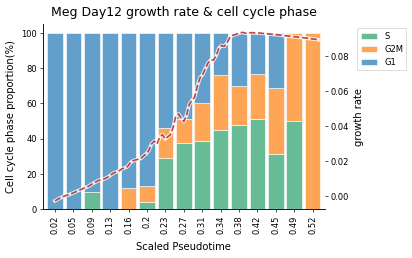

In [8]:
dpi = 60

ad = adata_lin['Meg']
color_palette = dict(zip(['G1','G2M','S'], ad.uns['phase_colors']))
print(ad.obs['pseudotime_bin'].unique())


fig = plt.figure(figsize=(7,4), dpi=dpi, frameon=False)
ax = fig.gca()

obs_composition(ad[ad.obs['timepoint_tx_days']<=12],
                             x_var='pseudotime_bin',y_var='phase',
                             palette = color_palette,
                             alpha = 0.7,
                             legend_kws={"bbox_to_anchor":(1.1, 1), "loc":'upper left'}, 
                             ax= ax);

ax2 = ax.twinx()

ax2.plot(np.linspace(0, nbins-0.7, projection_bins-1), g_project['Meg'][2], color='white', linewidth=4.5, alpha=0.8)
ax2.plot(np.linspace(0, nbins-0.7, projection_bins-1), g_project['Meg'][2], color="#b61a1ad1", linestyle='--', linewidth=2)
ax2.set_ylabel("growth rate", labelpad=6, fontsize=12)


ax.set_xlabel("Scaled Pseudotime", labelpad=10, fontsize=12)
ax.set_ylabel("Cell cycle phase proportion(%)", labelpad=6, fontsize=12)

ax.set_title("Meg Day12 growth rate & cell cycle phase", pad=10, fontsize=15)


if dpi == 600:
    fig.savefig("figures/tompos_growth_cellcycle/Meg_Day12_growth_cellcycle.pdf", dpi=dpi, transparent=True, bbox_inches='tight', pad_inches=0)

[0.38 0.34 0.31 0.27 0.42 0.45 0.23 0.52 0.49 0.2  0.16 0.13 0.09 0.05
 0.02]


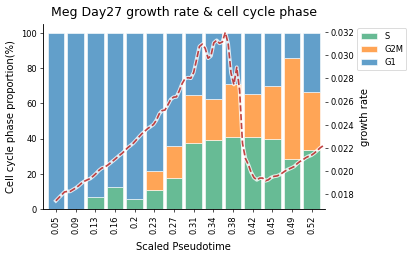

In [10]:
dpi = 60

ad = adata_lin['Meg']
color_palette = dict(zip(['G1','G2M','S'], ad.uns['phase_colors']))
print(ad.obs['pseudotime_bin'].unique())


fig = plt.figure(figsize=(7,4), dpi=dpi, frameon=False)
ax = fig.gca()

obs_composition(ad[ad.obs['timepoint_tx_days']==27],
                             x_var='pseudotime_bin',y_var='phase',
                             palette = color_palette,
                             alpha = 0.7,
                             legend_kws={"bbox_to_anchor":(1.1, 1), "loc":'upper left'}, 
                             ax= ax);

ax2 = ax.twinx()

ax2.plot(np.linspace(0, nbins-0.7, projection_bins-1), g_project['Meg'][3], color='white', linewidth=4.5, alpha=0.8)
ax2.plot(np.linspace(0, nbins-0.7, projection_bins-1), g_project['Meg'][3], color="#b61a1ad1", linestyle='--', linewidth=2)
ax2.set_ylabel("growth rate", labelpad=6, fontsize=12)


ax.set_xlabel("Scaled Pseudotime", labelpad=10, fontsize=12)
ax.set_ylabel("Cell cycle phase proportion(%)", labelpad=6, fontsize=12)

ax.set_title("Meg Day27 growth rate & cell cycle phase", pad=10, fontsize=15)


if dpi == 600:
    fig.savefig("figures/tompos_growth_cellcycle/Meg_Day27_growth_cellcycle.pdf", dpi=dpi, transparent=True, bbox_inches='tight', pad_inches=0)

In [16]:
dpi = 60

ad = adata_lin['Meg']
color_palette = dict(zip(['G1','G2M','S'], ad.uns['phase_colors']))
print(ad.obs['pseudotime_bin'].unique())


fig = plt.figure(figsize=(7,4), dpi=dpi, frameon=False)
ax = fig.gca()

obs_composition(ad[ad.obs['timepoint_tx_days']==161],
                             x_var='pseudotime_bin',y_var='phase',
                             palette = color_palette,
                             alpha = 0.7,
                             legend_kws={"bbox_to_anchor":(1.1, 1), "loc":'upper left'}, 
                             ax= ax);

ax2 = ax.twinx()

ax2.plot(np.linspace(0, nbins-0.7, projection_bins-1), g_project['Meg'][7], color='white', linewidth=4.5, alpha=0.8)
ax2.plot(np.linspace(0, nbins-0.7, projection_bins-1), g_project['Meg'][7], color="#b61a1ad1", linestyle='--', linewidth=2)
ax2.set_ylabel("growth rate", labelpad=6, fontsize=12)


ax.set_xlabel("Scaled Pseudotime", labelpad=10, fontsize=12)
ax.set_ylabel("Cell cycle phase proportion(%)", labelpad=6, fontsize=12)

ax.set_title("Meg Day161 growth rate & cell cycle phase", pad=10, fontsize=15)


if dpi == 600:
    fig.savefig("figures/tompos_growth_cellcycle/Meg_Day161_growth_cellcycle.pdf", dpi=dpi, transparent=True, bbox_inches='tight', pad_inches=0)

[0.38 0.34 0.31 0.27 0.42 0.45 0.23 0.52 0.49 0.2  0.16 0.13 0.09 0.05
 0.02]


In [7]:
adata_lin['Neu']

AnnData object with n_obs × n_vars = 23442 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [ ]:
# Compute cell cycle proportion and average G2M score along pseudotime bins for each lineage

def plot_cellcycle_growth(timepoint_i, select_day=False, save_path=None):
    """
    Plot cell cycle proportions and G2M scores along pseudotime for a given timepoint index.
    Args:
        timepoint_i (int): Index of the timepoint to plot.
    """
    dpi = 80 if save_path is None else 600
    day = ad_palantir.uns['pop']['t'][timepoint_i]
    cell_cycle_props = {}
    g2m_means = {}
    sscore_means = {}
    bin_centers = {}

    for lineage, ad in adata_lin.items():
        # Get pseudotime and G2M score
        if select_day is False:
            ad_day = ad
        else:
            ad_day = ad[ad.obs['timepoint_tx_days'] == day].copy()
        pdt = ad_day.obs['palantir_pseudotime'].values
        g2m = ad_day.obs['G2M_score'].values
        sscore = ad_day.obs['S_score'].values

        # Define bins
        bins = np.linspace(pdt.min(), pdt.max(), 11)
        bin_labels = 0.5 * (bins[:-1] + bins[1:])

        # Compute cell cycle proportion (S or G2M phase)
        is_cc = ad_day.obs['phase'].isin(['S', 'G2M']).values
        prop = []
        g2m_avg = []
        sscore_avg = []

        valided_bins = []
        for i in range(len(bins)-1):
            mask = (pdt >= bins[i]) & (pdt < bins[i+1])
            if mask.sum() > 0:
                prop.append(is_cc[mask].mean())
                g2m_avg.append(g2m[mask].mean())
                sscore_avg.append(sscore[mask].mean())
                valided_bins.append(bin_labels[i])
            # else:
            #     prop.append(np.nan)
            #     g2m_avg.append(np.nan)
            #     sscore_avg.append(np.nan)

        cell_cycle_props[lineage] = np.array(prop)
        g2m_means[lineage] = np.array(g2m_avg)  
        sscore_means[lineage] = np.array(sscore_avg)  

        bin_centers[lineage] = valided_bins

    # Plotting
    fig, axs = plt.subplots(2, 3, figsize=(13, 5), dpi=dpi,
                             gridspec_kw={'hspace':0.4, 'wspace':0.7})

    for idx, lineage in enumerate(['Neu', 'Meg', 'Ery']):
        # Cell cycle proportion
        ad = adata_lin[lineage]
        if select_day is False:
            ad_day = ad
        else:
            ad_day = ad[ad.obs['timepoint_tx_days'] == day].copy()

        pl.obs_composition(ad_day,x_var='pseudotime_bin',y_var='phase',
                                ax=axs[0,idx])
        

        # G2M score and g_project
        axs[1,idx].plot(bin_centers[lineage], g2m_means[lineage], color='blue', marker='o', label=f'G2M score')
        # axs[1,idx].plot(bin_centers[lineage], sscore_means[lineage], color='orange', marker='o', label=f'Day{day} S score')
        
        # only plot 
        pdt_mask = np.logical_and(x_project[lineage]>=bin_centers[lineage][0],
                                  x_project[lineage]<=bin_centers[lineage][-1])
        ax2 = axs[1,idx].twinx()
        ax2.plot(x_project[lineage][pdt_mask], g_project[lineage][timepoint_i][pdt_mask], color='green', label=f'growth')

        # ax3 = axs[idx].twinx()
        # ax3.plot(x_project[lineage], g_project[lineage][-2], color='orange', label='Day161 Growth')
        axs[0,idx].set_title(f"{lineage} Day{day} \n cell cycle phase & growth")
        axs[0,idx].set_ylabel('Cell cycle phase\n proportion')
        axs[1,idx].set_ylabel('Average G2M score')
        ax2.set_ylabel('Growth')
        axs[0,idx].set_xlabel('')
        axs[1,idx].set_xlabel('Pseudotime')

        
    
        # ax2.legend(frameon=False)

    axs[0,0].legend([], frameon=False)
    axs[0,1].legend([], frameon=False)

    # get the legend handle and label from ax2 and combine with axs[1,idx]
    handles1, labels1 = axs[1,idx].get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    axs[1,idx].legend(handles1+handles2, labels1+labels2, loc="lower right")

    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, transparent=True)
    # plt.show()
    return fig

/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/density_plot.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/density_plot.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/density_plot.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1541035/1542513732.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


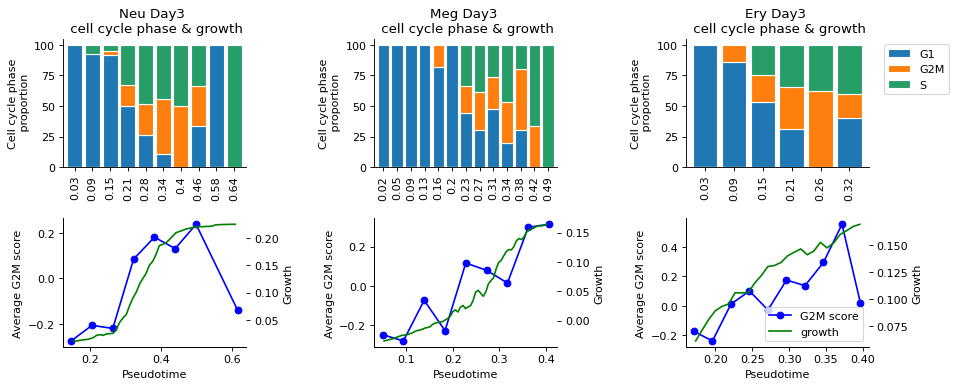

In [13]:
fig = plot_cellcycle_growth(0)

In [14]:
plt.ioff()
for i in range(1,9):
    day = ad_palantir.uns['pop']['t'][i]
    fig = plot_cellcycle_growth(i, 
    save_path=f'figures/tompos_growth_cellcycle/Day{day}_pdt.pdf')

    fig.show(False)

/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/density_plot.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/density_plot.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/density_plot.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1541035/1542513732.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/density_plot.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so result

# time invariance model

In [ ]:
inv_ckpt = "logs/tompos_leavout_t5n7/pde_params/lightning_logs/version_1/checkpoints/epoch=117-total_loss=1.91130519.ckpt"
inv_model = PINN.models.pde_params.load_from_checkpoint(inv_ckpt)

In [23]:
# loading saved parameters evaluted in `Explore_Notebook/6.simulation/6-5-2.evalute_tompos_time_invar.ipynb`
g_inv = np.load("results/tompos_leavout_t5n7/pde_params/V1/g.npy")
v_inv = np.load("results/tompos_leavout_t5n7/pde_params/V1/v_norm.npy")

In [25]:
adata_lin = {}
v_project = {}
g_project = {}
x_project = {}
pdt_bin_lineage = {}

nbins = 15

ad_palantir.obsm['v_norm'] = v_inv.T
ad_palantir.obsm['g'] = g_inv.T

for lineage in ['Neu', 'Meg', 'Ery']:
    ad = ad_palantir[ad_palantir.obsm['branch_masks'][lineage]].copy()
    pdt_max = ad.obs['palantir_pseudotime'].max()

    # Normalize the pseudotime

    projection_bins = 100
    x = np.linspace(0, pdt_max, projection_bins)
    x_project[lineage] = (x[1:] + x[:-1])/2
    v_project[lineage] = tl.aggregate_params_by_pseudotime(ad, ad.obsm['v_norm'].T, 
                                            param_names='v', timepoints=None, 
                                            pseudotime_key='palantir_pseudotime',
                                            nbins=projection_bins, return_y=True)

    g_project[lineage] = tl.aggregate_params_by_pseudotime(ad, ad.obsm['g'].T, 
                                            param_names='g', timepoints=None, 
                                            pseudotime_key='palantir_pseudotime',
                                            nbins=projection_bins, return_y=True)

    pdt_bins = np.linspace(0, pdt_max, nbins+1)
    pdt_bin_lineage[lineage] = pdt_bins
    pdt_label = np.round((pdt_bins[1:] + pdt_bins[:-1])/2, 2)
    ad.obs['pseudotime_bin'] = pd.cut(ad.obs['palantir_pseudotime']
                                            ,bins=nbins,labels = pdt_label).astype(float)
    
    adata_lin[lineage] = ad
    print(adata_lin[lineage].obs['pseudotime_bin'].unique())

[0.34 0.64 0.28 0.4  0.21 0.46 0.15 0.52 0.58 0.77 0.71 0.89 0.83 0.09
 0.03]
[0.38 0.34 0.31 0.27 0.42 0.45 0.23 0.52 0.49 0.2  0.16 0.13 0.09 0.05
 0.02]
[0.26 0.32 0.62 0.21 0.56 0.38 0.5  0.68 0.44 0.15 0.73 0.79 0.85 0.09
 0.03]


In [29]:
plt.ioff()
i = 0

day = ad_palantir.uns['pop']['t'][i]
fig = plot_cellcycle_growth(i, 
        select_day=False,
        save_path=f'figures/tompos_growth_cellcycle/T-inv_model_pdt.pdf')

fig.show(False)

/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/density_plot.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/density_plot.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/density_plot.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1541035/1575115546.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
